In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# User Inputs

In [137]:
# ----- Temperature and Pressure -----
T = 25 + 273.15 # K
P = 0.101325 * 1e6 # Pa

# ----- Ion concentrations in the brine in mol/kg -----
# [Na, K, Mg, Ca, Cl, SO4, NO3]
ion_conc_arr = [
    [0.0, 0, 0, 0, 0.0, 0, 0],
    [0.5, 0, 0, 0, 0.5, 0, 0],
    [1.0, 0, 0, 0, 1.0, 0, 0],
    [1.5, 0, 0, 0, 1.5, 0, 0],
    [2.0, 0, 0, 0, 2.0, 0, 0],
    [2.5, 0, 0, 0, 2.5, 0, 0],
    [3.0, 0, 0, 0, 3.0, 0, 0],
    [3.5, 0, 0, 0, 3.5, 0, 0],
    [4.0, 0, 0, 0, 4.0, 0, 0],
    [4.5, 0, 0, 0, 4.5, 0, 0],
    [5.0, 0, 0, 0, 5.0, 0, 0]
]

# ----- Parameters for plot -----
scenario = f"at P = {(P / 1e6):.1f} MPa and T = {(T - 273.15):.1f} °C"
NaCl_conc = [ion_conc[0] for ion_conc in ion_conc_arr]

# Experimental Data

**Reference:**

* Markham and Kobe (1941): [The Solubility of Carbon Dioxide and Nitrous Oxide in Aqueous Salt Solutions](https://doi.org/10.1021/ja01847a027)
* Yasunishi and Yoshida (1979): [Solubility of carbon dioxide in aqueous electrolyte solutions](https://doi.org/10.1021/je60080a007)
* Moore et al. (1982): [Partial molar volumes of gases at infinite dilution in water at 298.15 K](https://doi.org/10.1021/je00027a005)

In [117]:
# CO2 solubility at 0.1 MPa and 25 °C
markham_kobe = {
    "NaCl_mol_kg": [0, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0, 4.0],
    "solubility_mol_mol": np.array([6.09, 5.95, 5.80, 5.39, 4.79, 3.88, 3.16, 2.65])*1e-4
}

yasunishi_yoshida = {
    "NaCl_mol_kg": [0.455, 1.000, 1.442, 1.945, 2.486, 3.098, 3.400, 4.216, 5.096],
    "solubility_mol_mol": np.array([5.42, 4.80, 4.31, 3.83, 3.44, 2.98, 2.75, 2.32, 1.91])*1e-4
}

# CO2-saturated water density at 0.1 MPa and 25 °C
moore = {
    "NaCl_mol_kg": 0,
    "density_kg_m3": 996.345
}

# Model Parameters

**Reference:**

Smith et al. (2025): [Extended Søreide-Whitson equation of state for CO2-brine equilibrium using an ion-specific parameterisation](https://doi.org/10.1016/j.jgsce.2025.205684)

In [118]:
# --- CO2 and Brine System ---
Names = {'CO2' 'H2O'}
zi = np.array([0.5, 0.5]) # overall composition
Tc = np.array([304.128, 647.096]) # in Kelvin
Pc = np.array([7.3773, 22.064])*1e6 # in Pa
omega  = np.array([0.22394, 0.3443]) # accentric factors
MW = np.array([44.0098, 18.0153]) # in g/mol
Nc = zi.size # number of components
EOS = 'PR' # Equation of State we are interested to use
R = 8.314 # gas constant (J/mol-K)
T_c_water = 647.096 # water critical temperature (K)
tol  = 1e-5
max_iterations = 100

# --- Søreide-Whitson (SW) Model Parameters ---

# Ion-specific coefficients for alpha-salt (Eq. 4)
# From Table 3; values below are already scaled (e-3). Do NOT rescale in code.
C_alpha = {
    "Na+":   [2.11047e-3, -0.56270e-3, -0.13404e-3],
    "K+":    [1.51363e-3, -0.10378e-3, -0.35029e-3],
    "Mg2+":  [1.03320e-3, -0.72458e-3,  0.53085e-3],
    "Ca2+":  [-0.61563e-3, 0.68377e-3,  -0.27446e-3],
    "Cl-":   [2.98632e-3, -1.01891e-3,  0.29473e-3],
    "SO4_2-":[-0.54218e-3, 0.83759e-3,  -0.03364e-3],
    "NO3-":  [3.99740e-3, -1.63534e-3,  0.14686e-3],
}

# Ion-specific coefficients for kij-salt (Eq. 8)
# From Table 7; values are ready to use as-is.
A_kij = {
    "Na+":   [0.075845, -0.260250e-3, -0.271566, 0.253033],
    "K+":    [0.037792,  1.692832e-3, -0.177191, 0.171738],
    "Mg2+":  [0.084655, -1.102374e-3, -0.309761, 0.314991],
    "Ca2+":  [0.009831, -0.939877e-3, -0.025216, 0.055317],
    "Cl-":   [0.034833, -0.304342e-3, -0.121092, 0.125324],
    "SO4_2-":[0.087618,  1.422841e-3, -0.272174, 0.287258],
    "NO3-":  [0.032243,  0.607413e-3, -0.155869, 0.164632],
}

# Helper Functions

## Flash and EOS

In [119]:
def SolveRachfordRice(l, Nc, z, K, iteration_arr, error_arr):

    def RachfordRice_equation(l):
        return np.sum(z * (1 - K) / (K + (1 - K) * l))

    def dF_dl_equation(l):
        return np.sum(-z * (1 - K)**2 / (K + (1 - K) * l)**2)

    conv = 0
    tol = 1e-5
    iteration = 0
    max_iterations = 100

    # --- Mixed Newton Bisection Method ---

    # step 1: check for existence of solution
    F_0 = RachfordRice_equation(0)
    F_1 = RachfordRice_equation(1)
    if F_0 > 0 and F_1 < 0:
        l_min = 0
        l_max = 1
    elif F_0 < 0 and F_1 < 0:
        l_min = np.min(np.divide(z - K, 1 - K))
        l_max = 0
    else:
        l_min = 1
        l_max = np.max(np.divide(K * z - K, 1 - K))

    # step 2: check for tighter bounds then update l_min and l_max as needed
    if np.min(np.divide(z - K, 1 - K)) > 0:
        l_min = np.min(np.divide(z - K, 1 - K))
    if np.max(np.divide(K * z - K, 1 - K)) < 1:
        l_max = np.max(np.divide(K * z - K, 1 - K))

    # step 3: update initial guess by bisecting
    l_init = 0.5 * (l_min + l_max)
    f_l_init = RachfordRice_equation(l_init)
    if f_l_init > 0:
        l_min = l_init
    else:
        l_max = l_init

    # step 4: iterate for l
    l = l_init
    while conv == 0 and iteration < max_iterations:
        # calculate a Newton update
        F_l = RachfordRice_equation(l)
        dF_dl = dF_dl_equation(l)

        if dF_dl == 0 or np.isnan(dF_dl):
            l_new = 0.5 * (l_min + l_max)
        else:
            l_new = l -F_l / dF_dl

            # validate the Newton update
            if not (l_min < l_new < l_max):
                l_new = 0.5 * (l_min + l_max)

        # check bounds
        F_new = RachfordRice_equation(l_new)
        if F_new > 0:
            l_min = l_new
        else:
            l_max = l_new

        delta_l = l_new - l
        l = l_new

        # check for convergence
        if abs(delta_l) < tol:
            conv = 1

        # update number of iterations
        iteration += 1

        # report errors iteration-by-iteration
        iteration_arr.append(iteration)
        error_arr.append(abs(delta_l))

    # final clamp if l is out of range
    l = np.clip(l, 0, 1)

    return l

In [120]:
def kij(phase, T_r_water, ion_conc):
    k_CO2_water = 0.29809 - 0.18737/T_r_water

    # loop through each ion
    i = 0
    k_CO2_salt = 0
    for value in A_kij.values():
        k_CO2_salt += value[0]*ion_conc[i] + value[1]*ion_conc[i]**2 + value[2]*ion_conc[i]*T_r_water + value[3]*ion_conc[i]*T_r_water**2
        i += 1

    k_CO2_brine = k_CO2_water + k_CO2_salt

    if phase == 'NA':
        return np.array([[0, 0.19149],
                        [0.19149, 0]])
    elif phase == 'AQ':
        return np.array([[0, k_CO2_brine],
                        [k_CO2_brine, 0]])

In [121]:
def calc_a(EOS, T_r_water, ion_conc, T, Tc, Pc, omega):
    """
    calculates ai for each component for the EOS of interest

    EOS: Equation of state (PR, SRK, or RK)
    T, Tc: temperature and critical temperature of the component
    Pc: critical pressure of the component
    omega: accentric factor for the component
    """

    alpha_water = 1 + 0.919669*(1-np.sqrt(T_r_water)) - 0.33799*(1-np.sqrt(T_r_water))**2 + 0.333663*(1-np.sqrt(T_r_water))**3

    # loop through each ion
    i = 0
    alpha_salt = 0
    for value in C_alpha.values():
        alpha_salt += value[0]*ion_conc[i] + value[1]*ion_conc[i]/T_r_water + value[2]*ion_conc[i]**2
        i += 1

    alpha_brine = (alpha_water + alpha_salt)**2

    if EOS == 'PR':
        fw = 0.37464 + 1.54226*omega - 0.26992*omega**2
        a1 = np.divide(0.45724*R**2*Tc**2, Pc)
        a2_NA = (1 + np.multiply(fw, (1 - np.sqrt(np.divide(T, Tc)))))**2
        a2 = np.array([a2_NA[0], alpha_brine])
        a  = np.multiply(a1, a2)
    elif EOS == 'SRK':
        fw = 0.48 + 1.574*omega - 0.176*omega**2
        a1 = np.divide((0.42748*R**2*Tc**2), Pc)
        a2 = (1 + np.multiply(fw, (1 - np.sqrt(np.divide(T, Tc)))))**2
        a  = np.multiply(a1, a2)
    elif EOS == 'RK':
        a = np.divide(0.42748*R**2*Tc**(5/2), (Pc*T**0.5))
    else:
        print('parameters for this EOS is not defined')
    return a


def calc_b(EOS, Tc, Pc):
    """
    calculates ai for each component for the EOS of interest

    EOS: Equation of state (PR, SRK, or RK)
    Tc: critical temperature of the component
    Pc: critical pressure of the component
    """

    # The below if statement computes b for each
    # componenet based on the EOS of
    # interest (Table 5.1 in the course reader)
    if EOS == 'PR':
        b = np.divide(0.07780*R*Tc, Pc)
    elif EOS == 'SRK':
        b = np.divide(0.08664*R*Tc, Pc)
    elif EOS == 'RK':
        b = np.divide(0.08664*R*Tc ,Pc)
    return b

In [122]:
def find_am(EOS, phase, T_r_water, ion_conc, y, T, Tc, Pc, omega):
    """
    calculates the a parameter for the EOS of interest

    EOS: equation of state of interest (PR, SRK, RK)
    y: vapor or liquid compositions
    T, Tc: temperature value and critical temperature array
    Pc: critical pressure array
    omega: accentric factors array
    """

    kijs = kij(phase, T_r_water, ion_conc)
    a = calc_a(EOS, T_r_water, ion_conc, T, Tc, Pc, omega)
    am = sum(
        y[i] * y[j] * np.sqrt(a[i] * a[j]) * (1 - kijs[i,j])
        for i in range(len(y))
        for j in range(len(y))
    )
    return am


def find_bm(EOS, y, Tc, Pc):
    """
    This function computes the b for the mixture for the EOS of interest

    EOS: Equation of state (PR, SRK, or RK)
    y: liquid or vapor compositions array
    Tc and Pc: critical temperature and pressure array
    """

    bm = np.sum(y * calc_b(EOS, Tc, Pc))
    return bm

In [123]:
def choose_physical_root(EOS, phase, T_r_water, ion_conc, comp, T, Tc, Pc, omega, P, a, b):
    """
    Choose the physical Z root for a given phase composition.

    phase   : 'NA' for vapor, 'AQ' for liquid
    comp    : yi or xi
    am, bm  : phase mixture parameters for this composition
    """

    roots = Z_factor(EOS, P, T, a, b)

    if len(roots) == 0:
      raise ValueError("No real Z roots found.")

    if len(roots) == 1:
      return roots[0]

    # only smallest and largest are candidates
    Z_small = roots[0]
    Z_large = roots[-1]

    # fugacity at each candidate root
    fug_small = get_fug(EOS, phase, T_r_water, ion_conc, comp, Z_small, Tc, Pc, P, T, omega, a, b)
    fug_large = get_fug(EOS, phase, T_r_water, ion_conc, comp, Z_large, Tc, Pc, P, T, omega, a, b)

    # convert fugacity to fugacity coefficient
    phi_small = fug_small / (comp * P)
    phi_large = fug_large / (comp * P)

    # avoid log(0)
    phi_small = np.maximum(phi_small, 1e-300)
    phi_large = np.maximum(phi_large, 1e-300)

    # compare dimensionless Gibbs energy contribution
    g_small = np.sum(comp * np.log(phi_small))
    g_large = np.sum(comp * np.log(phi_large))

    return Z_small if g_small < g_large else Z_large

In [124]:
def Z_factor(EOS, P, T, a, b):
    """
    This function computes the Z factor for the cubic EOS of interest

    EOS: equation of state (PR, SRK, or RK)
    P, T: pressure and temperature
    a, b: the vapor or liquid parameters of equation of state
    """

    if EOS == 'PR':
        u = 2
        w = -1
    elif EOS == 'SRK':
        u = 1
        w = 0
    elif EOS == 'RK':
        u = 1
        w = 0

    A = np.divide(a*P, R**2*T**2)
    B = np.divide(b*P, R*T)

    Coeffs = list()
    Coeffs.append(1)
    Coeffs.append(-(1 + B - u*B))
    Coeffs.append(A + w*B**2 - u*B - u*B**2)
    Coeffs.append(-np.multiply(A, B) - w*B**2 - w*B**3)

    Z = np.roots(Coeffs)
    # remove the roots with imaginary parts
    Z = np.real(Z[np.imag(Z) == 0])
    return Z

In [125]:
def get_fug(EOS, phase, T_r_water, ion_conc, y, Z, Tc, Pc, P, T, omega, a, b):
    """
    This function computes the liquid or vapor fugacity of all components
    using Eq. 6.8 in course reader

    parameters needed:
    EOS: equation of state (PR, SRK, or RK)
    y: liquid or vapor compositions
    Z: z-factors for vapor or liquid
    Tc and Pc: critical temperature and pressure for all individual comp.s
    P, T: pressure and temperature of the system
    omega: accentric factors for all individual components
    a and b: EOS parameters as computed in another function
    """

    if EOS == 'PR':
        u = 2
        w = -1
        kijs = kij(phase, T_r_water, ion_conc)
    elif EOS == 'SRK':
        u = 1
        w = 0
        kijs = kij(phase, T_r_water, ion_conc)
    elif EOS == 'RK':
        u = 1
        w = 0
        kijs = kij(phase, T_r_water, ion_conc)

    fug = np.zeros(y.shape)
    A_star = a * P / (R**2 * T**2)
    B_star = b * P / (R * T)
    ai = calc_a(EOS, T_r_water, ion_conc, T, Tc, Pc, omega)
    bi_over_b = Tc / Pc / np.sum(y * Tc / Pc)
    delta_i = 2 * np.sqrt(ai) / a * np.sum(y * np.sqrt(ai) * (1 - kijs), axis=1)
    fug = y * P * np.exp(bi_over_b*(Z-1) - np.log(Z-B_star) + A_star/(B_star*np.sqrt(u**2-4*w))\
                           * (bi_over_b-delta_i) * np.log((2*Z+B_star*(u+np.sqrt(u**2-4*w)))\
                                                            / (2*Z+B_star*(u-np.sqrt(u**2-4*w)))))

    return fug

## Solubility Calculation

In [126]:
def calc_CO2_solubility(T, P, ion_conc_arr, CO2_solubility_arr, CO2_solubility_corrected_arr, zi, Tc, Pc, omega, Mw, Nc, EOS, tol, max_iterations):

    T_r_water = T/T_c_water

    for ion_conc in ion_conc_arr:
        conv = 0
        iteration = 0

        # guess initial K-values from Wilson equation
        Ki = Pc/P * np.exp(5.37*(1+omega)*(1 - Tc/T))

        # guess initial l
        l = 0.5

        while conv == 0 and iteration < max_iterations:
            l_initial = l
            iteration_arr = []
            error_arr = []
            l = SolveRachfordRice(l_initial, Nc, zi, Ki, iteration_arr, error_arr)
            v = 1-l

            # calculate liquid and gas compositions (Eq. 6.15 and 6.16, respectively)
            xi = np.divide(zi, l+(1-l)*Ki)
            yi = np.divide(np.multiply(Ki, zi), (l+(1-l)*Ki))

            # calculate the a's and b's of the vapor and liquid phases
            av = find_am(EOS, 'NA', T_r_water, ion_conc, yi, T, Tc, Pc, omega)
            al = find_am(EOS, 'AQ', T_r_water, ion_conc, xi, T, Tc, Pc, omega)

            bv = find_bm(EOS, yi, Tc, Pc)
            bl = find_bm(EOS, xi, Tc, Pc)

            # calculate the vapor and liquid Z-factors
            Zv = choose_physical_root(EOS, 'NA', T_r_water, ion_conc, yi, T, Tc, Pc, omega, P, av, bv)
            Zl = choose_physical_root(EOS, 'AQ', T_r_water, ion_conc, xi, T, Tc, Pc, omega, P, al, bl)

            # calculate the vapor and liquid volumes from PV = ZRT
            Vv = np.divide(Zv*R*T, P)
            Vl = np.divide(Zl*R*T, P)

            # calculate fugacity values of vapor and liquid
            fug_v = get_fug(EOS, 'NA', T_r_water, ion_conc, yi, Zv, Tc, Pc, P, T, omega, av, bv)
            fug_l = get_fug(EOS, 'AQ', T_r_water, ion_conc, xi, Zl, Tc, Pc, P, T, omega, al, bl)

            # update number of iterations
            iteration += 1

            # check for convergence
            if np.all(np.abs(np.divide(fug_l, fug_v) - 1) < tol):
                conv = 1
            else:
                # update Ki values
                Ki *= np.divide(fug_l, fug_v)

        if conv == 1:
            CO2_solubility = float(xi[0])

            # corrected solubility by experimental data
            CO2_solubility_corrected = float(xi[0])**1.4931 * 56.348
        else:
            CO2_solubility = -1

        CO2_solubility_arr.append(CO2_solubility)
        CO2_solubility_corrected_arr.append(CO2_solubility_corrected)

## Density Calculations

**Reference:**

* Batzle and Wang (1992): [Seismic properties of pore fluids](https://doi.org/10.1190/1.1443207)
* Haas (1970): [An Equation for the Density of Vapor-Saturated NaCl-H 2 O Solutions From 75 Degrees to 325 Degrees C](https://doi.org/10.2475/ajs.269.5.489)

In [127]:
# --------------- Batzle and Wang (1992) ---------------
def calc_pure_water_density(T_Kelvin, P_Pa):
    T = T_Kelvin - 273.15 # convert T from Kelvin to Celcius
    P = P_Pa / 1e6 # convert P from Pa to MPa
    rho_water = 1 + 1e-6*(-80*T - 3.3*T**2 + 0.00175*T**3 + 489*P - 2*T*P
                          + 0.016*T**2*P - 1.3*1e-5*T**3*P - 0.333*P**2 - 0.002*T*P**2) # g/cm3

    return rho_water


# --------------- Haas (1970) ---------------
def calc_brine_density(rho_water, m_s, Mw_s):
    # constants from Haas (1970)
    a1 = -13.644
    a2 = 13.97
    b1 = -167.219
    b2 = 448.55
    b3 = -261.07

    v_water = 1/rho_water
    phi_0 = b1 + b2*v_water + b3*v_water**2
    S = (a1 + a2*v_water) * (3.197 / (3.197-v_water))**2
    phi_v = phi_0 + S*np.sqrt(m_s)
    rho_brine = (1000 + m_s*Mw_s) / (1000*v_water + m_s*phi_v) # g/cm3

    return rho_brine


def calc_solution_density(T, P, ion_conc_arr, rho_water_arr, rho_brine_arr, rho_sol_arr, rho_sol_corrected_arr, zi, Tc, Pc, omega, Mw, Nc, EOS, tol, max_iterations):
    T_r_water = T/T_c_water
    Mw_s = 58.44 # NaCl in g/mol

    for ion_conc in ion_conc_arr:
        conv = 0
        iteration = 0
        m_s = ion_conc[0] # Na+ concentration in mol/kg

        # guess initial K-values from Wilson equation
        Ki = Pc/P * np.exp(5.37*(1+omega)*(1 - Tc/T))

        # guess initial l
        l = 0.5

        while conv == 0 and iteration < max_iterations:
            l_initial = l
            iteration_arr = []
            error_arr = []
            l = SolveRachfordRice(l_initial, Nc, zi, Ki, iteration_arr, error_arr)
            v = 1-l

            # calculate liquid and gas compositions (Eq. 6.15 and 6.16, respectively)
            xi = np.divide(zi, l+(1-l)*Ki)
            yi = np.divide(np.multiply(Ki, zi), (l+(1-l)*Ki))

            # calculate the a's and b's of the vapor and liquid phases
            av = find_am(EOS, 'NA', T_r_water, ion_conc, yi, T, Tc, Pc, omega)
            al = find_am(EOS, 'AQ', T_r_water, ion_conc, xi, T, Tc, Pc, omega)

            bv = find_bm(EOS, yi, Tc, Pc)
            bl = find_bm(EOS, xi, Tc, Pc)

            # calculate the vapor and liquid Z-factors
            Zv = choose_physical_root(EOS, 'NA', T_r_water, ion_conc, yi, T, Tc, Pc, omega, P, av, bv)
            Zl = choose_physical_root(EOS, 'AQ', T_r_water, ion_conc, xi, T, Tc, Pc, omega, P, al, bl)

            # calculate the vapor and liquid volumes from PV = ZRT
            Vv = np.divide(Zv*R*T, P)
            Vl = np.divide(Zl*R*T, P)

            # calculate fugacity values of vapor and liquid
            fug_v = get_fug(EOS, 'NA', T_r_water, ion_conc, yi, Zv, Tc, Pc, P, T, omega, av, bv)
            fug_l = get_fug(EOS, 'AQ', T_r_water, ion_conc, xi, Zl, Tc, Pc, P, T, omega, al, bl)

            # update number of iterations
            iteration += 1

            # check for convergence
            if np.all(np.abs(np.divide(fug_l, fug_v) - 1) < tol):
                conv = 1
            else:
                # update Ki values
                Ki *= np.divide(fug_l, fug_v)

        if conv == 1:
            CO2_solubility = float(xi[0])
            mass_water = float(xi[1]) * Mw[1] / 1000 # kg

            # corrected solubility by experimental data
            CO2_solubility_corrected = float(xi[0])**1.4931 * 56.348
            mass_water_corrected = (1 - CO2_solubility_corrected) * Mw[1] / 1000 # kg

            m_CO2 = CO2_solubility / mass_water
            m_CO2_corrected = CO2_solubility_corrected / mass_water_corrected

            # calculate density of pure water and CO2-free brine
            rho_water = calc_pure_water_density(T, P) # g/cm3
            rho_brine = calc_brine_density(rho_water, m_s, Mw_s) # g/cm3

            # calculate CO2 partial molar volume
            dP = 1e-3 * P
            Zl1 = choose_physical_root(EOS, 'AQ', T_r_water, ion_conc, xi, T, Tc, Pc, omega, P, al, bl)
            fug_l1 = get_fug(EOS, 'AQ', T_r_water, ion_conc, xi, Zl1, Tc, Pc, P, T, omega, al, bl)
            Zl2 = choose_physical_root(EOS, 'AQ', T_r_water, ion_conc, xi, T, Tc, Pc, omega, P+dP, al, bl)
            fug_l2 = get_fug(EOS, 'AQ', T_r_water, ion_conc, xi, Zl2, Tc, Pc, P+dP, T, omega, al, bl)
            dln_fug = np.log(fug_l2[0]) - np.log(fug_l1[0])
            vbar_CO2 = R*T*(dln_fug/dP)

            # calculate density of CO2-sat brine
            rho_sol = (1 + m_s*Mw_s/1000 + m_CO2*Mw[0]/1000) / ((1 + m_s*Mw_s/1000)/(rho_brine*1000) + m_CO2*vbar_CO2)
            rho_sol_corrected = (1 + m_s*Mw_s/1000 + m_CO2_corrected*Mw[0]/1000) / ((1 + m_s*Mw_s/1000)/(rho_brine*1000) + m_CO2_corrected*vbar_CO2)

        else:
            rho_sol = -1

        # store values
        rho_water_arr.append(rho_water*1000) # kg/m3
        rho_brine_arr.append(rho_brine*1000) # kg/m3
        rho_sol_arr.append(rho_sol) # kg/m3
        rho_sol_corrected_arr.append(rho_sol_corrected) # kg/m3

# Main Code

In [128]:
T_r_water = T/T_c_water

# CO2 solubility
CO2_solubility = []
CO2_solubility_corrected = []
calc_CO2_solubility(T, P, ion_conc_arr, CO2_solubility, CO2_solubility_corrected, zi, Tc, Pc, omega, MW, Nc, EOS, tol, max_iterations)

# density
rho_water = []
rho_brine = []
rho_sol = []
rho_sol_corrected = []
calc_solution_density(T, P, ion_conc_arr, rho_water, rho_brine, rho_sol, rho_sol_corrected, zi, Tc, Pc, omega, MW, Nc, EOS, tol, max_iterations)

# results
results = pd.DataFrame({
    "NaCl_concentration_mol/kg": NaCl_conc,
    "CO2_solubility_mol/mol": CO2_solubility,
    "CO2_solubility_mol/kg": np.array(CO2_solubility)/((1-np.array(CO2_solubility))*18.015/1000),
    "density_water_kg/m3": rho_water,
    "density_brine_kg/m3": rho_brine,
    "density_solution_kg/m3": rho_sol_corrected,
    "delta_rho_kg/m3": np.array(rho_sol_corrected) - np.array(rho_brine)
})

# Results and Plots

In [132]:
results

,NaCl_concentration_mol/kg,CO2_solubility_mol/mol,CO2_solubility_mol/kg,density_water_kg/m3,density_brine_kg/m3,density_solution_kg/m3,delta_rho_kg/m3
0,0.0,0.000476,0.026450,996.010314,996.010314,996.399569,0.389255
1,0.5,0.000437,0.024252,996.010314,1014.735979,1015.056062,0.320083
2,1.0,0.000402,0.022304,996.010314,1032.846618,1033.110649,0.264031
3,1.5,0.000370,0.020573,996.010314,1050.432651,1050.651077,0.218426
4,2.0,0.000343,0.019034,996.010314,1067.532523,1067.713711,0.181188
5,2.5,0.000318,0.017662,996.010314,1084.172591,1084.323270,0.150679
6,3.0,0.000296,0.016437,996.010314,1100.373770,1100.499369,0.125599
7,3.5,0.000276,0.015342,996.010314,1116.153889,1116.258804,0.104915
8,4.0,0.000259,0.014363,996.010314,1131.528778,1131.616578,0.087800
9,4.5,0.000243,0.013485,996.010314,1146.512840,1146.586433,0.073593


## Solubility Plot

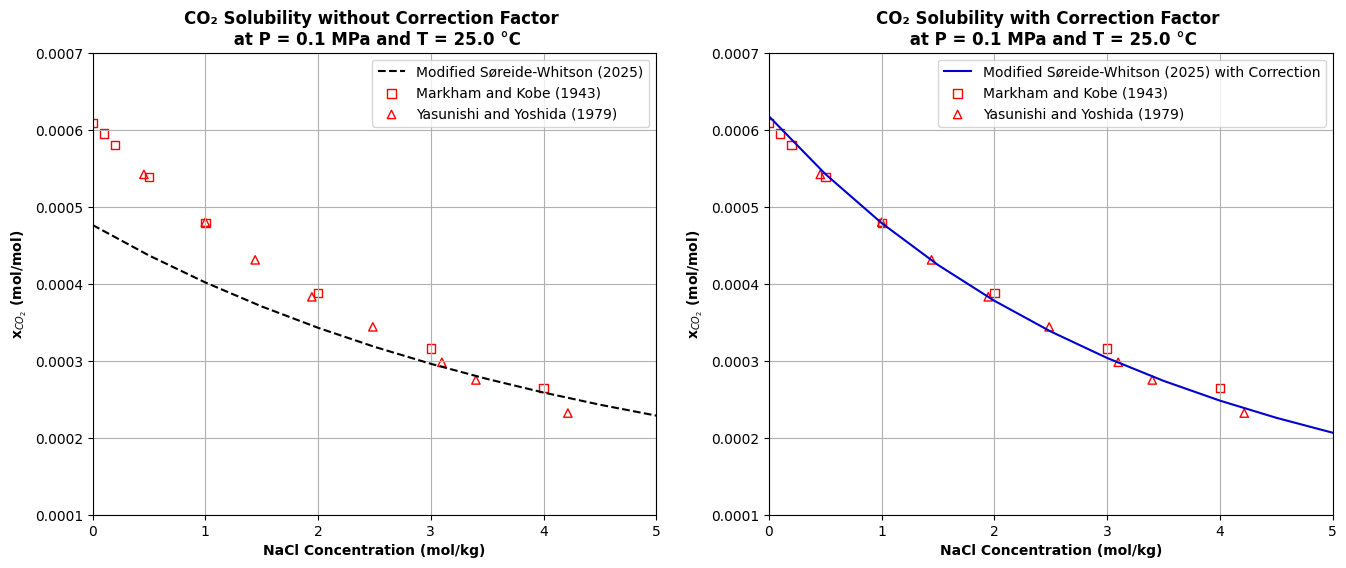

In [129]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(NaCl_conc, CO2_solubility, label='Modified Søreide-Whitson (2025)', color='black', linestyle='--')
plt.scatter(markham_kobe["NaCl_mol_kg"], markham_kobe["solubility_mol_mol"], label='Markham and Kobe (1943)', facecolors='none', edgecolors='red', marker='s')
plt.scatter(yasunishi_yoshida["NaCl_mol_kg"], yasunishi_yoshida["solubility_mol_mol"], label='Yasunishi and Yoshida (1979)', facecolors='none', edgecolors='red', marker='^')
plt.xlabel('NaCl Concentration (mol/kg)', fontweight='bold')
plt.ylabel(r'x$_{CO_2}$ (mol/mol)', fontweight='bold')
plt.title(f'CO₂ Solubility without Correction Factor \n {scenario}', fontweight='bold')
plt.xlim(0, 5)
plt.ylim(0.0001, 0.0007)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(NaCl_conc, CO2_solubility_corrected, label='Modified Søreide-Whitson (2025) with Correction', color='mediumblue')
plt.scatter(markham_kobe["NaCl_mol_kg"], markham_kobe["solubility_mol_mol"], label='Markham and Kobe (1943)', facecolors='none', edgecolors='red', marker='s')
plt.scatter(yasunishi_yoshida["NaCl_mol_kg"], yasunishi_yoshida["solubility_mol_mol"], label='Yasunishi and Yoshida (1979)', facecolors='none', edgecolors='red', marker='^')
plt.xlabel('NaCl Concentration (mol/kg)', fontweight='bold')
plt.ylabel(r'x$_{CO_2}$ (mol/mol)', fontweight='bold')
plt.title(f'CO₂ Solubility with Correction Factor \n {scenario}', fontweight='bold')
plt.xlim(0, 5)
plt.ylim(0.0001, 0.0007)
plt.legend()
plt.grid(True)
plt.show()

## Density Plot

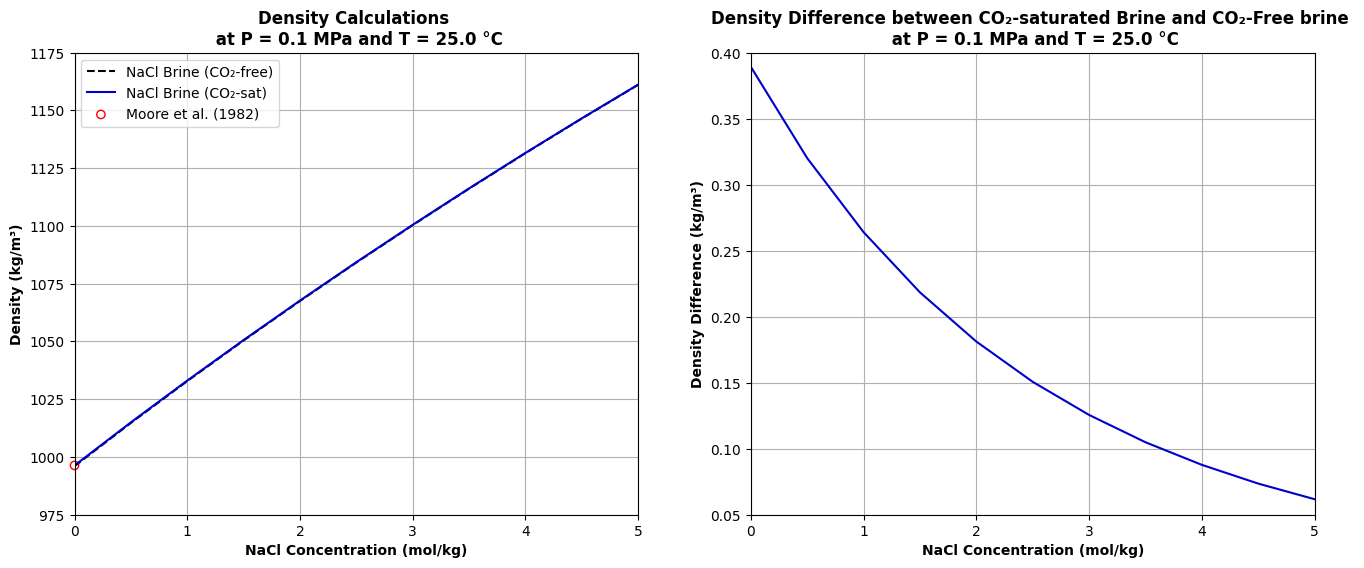

In [135]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(NaCl_conc, rho_brine, label='NaCl Brine (CO₂-free)', color='black', linestyle='--')
plt.plot(NaCl_conc, rho_sol, label='NaCl Brine (CO₂-sat)', color='mediumblue')
plt.scatter(moore["NaCl_mol_kg"], moore['density_kg_m3'], label='Moore et al. (1982)', facecolors='none', edgecolors='red', clip_on=False)
plt.xlabel('NaCl Concentration (mol/kg)', fontweight='bold')
plt.ylabel('Density (kg/m³)', fontweight='bold')
plt.title(f'Density Calculations \n {scenario}', fontweight='bold')
plt.xlim(0, 5)
plt.ylim(975, 1175)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(NaCl_conc, results["delta_rho_kg/m3"], color='mediumblue')
plt.xlabel('NaCl Concentration (mol/kg)', fontweight='bold')
plt.ylabel('Density Difference (kg/m³)', fontweight='bold')
plt.title(f'Density Difference between CO₂-saturated Brine and CO₂-Free brine \n {scenario}', fontweight='bold')
plt.xlim(0, 5)
plt.ylim(0.05, 0.40)
plt.grid(True)
plt.show()